## ANN AND CNN:



## ANN:
ANN is suitable for tabular structured data, so we applied it on loan/housing dataset.

In [ ]:
!pip install tensorflow

In [18]:
# 1. Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("loan_data.csv")

# Preprocessing
df_num = df.select_dtypes(include=[np.number])
df_num = df_num.fillna(df_num.mean())

# Target (last column)
y = df_num.iloc[:, -1]
X = df_num.drop(df_num.columns[-1], axis=1)

# Convert to classification
y = (y > y.mean()).astype(int)

In [7]:
# 2. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# 3. Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# 4. ANN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/Users/apple/Desktop/mlpython/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.8393 - loss: 0.4697 - val_accuracy: 0.8415 - val_loss: 0.4340
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.8393 - loss: 0.4294 - val_accuracy: 0.8415 - val_loss: 0.4240
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.8393 - loss: 0.4228 - val_accuracy: 0.8415 - val_loss: 0.4208
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.8393 - loss: 0.4198 - val_accuracy: 0.8415 - val_loss: 0.4195
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.8393 - loss: 0.4178 - val_accuracy: 0.8415 - val_loss: 0.4182
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.8393 - loss: 0.4164 - val_accuracy: 0.8415 - val_loss: 0.4173
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - accuracy: 0.8393 - loss: 0.4151 - val_accuracy: 0.8415 - val_loss: 0.4171
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - accuracy: 0.8393 - loss: 0.4144 - 

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.8413 - loss: 0.4074
Test Accuracy: 0.8413361310958862
Test Loss: 0.40735042095184326


In [13]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

print(y_pred[:10])

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]


In [14]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1606    5]
 [ 299    6]]


In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8413361169102297


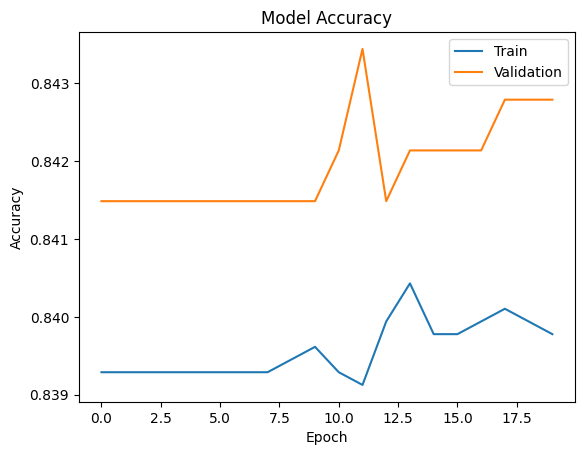

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()